In [115]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
import spiceypy as spy

In [116]:
G = 1

m1 = 1
r1_vec_0 = np.array([0,0,0])
v1_vec_0 = r1_vec_0.copy()

m2 = 1
r2_vec_0 = np.array([1,0,0])
v2_vec_0 = np.array([0.5,1,0])

El que tiene solucion es el problema relativo

In [117]:
r_vec_0 = r1_vec_0 - r2_vec_0
r0 = np.linalg.norm(r_vec_0) #magnitud en tiempo 0
v_vec_0 = v1_vec_0 - v2_vec_0
v0 = np.linalg.norm(v_vec_0) #magnitud en tiempo 0
mu = G * (m1 + m2)

Cuadraturas del problema

In [118]:
h_vec = np.cross(r_vec_0, v_vec_0) #M.A.R.E
h = np.linalg.norm(h_vec)
print(h_vec,h)

[0. 0. 1.] 1.0


In [119]:
e_vec = np.cross(v_vec_0, h_vec)/mu - r_vec_0/r0 #vector de Laplace
e = np.linalg.norm(e_vec)
print(e_vec, e) 

[0.5  0.25 0.  ] 0.5590169943749475


In [120]:
epsilon = v0**2/2 - mu/r0 #E.R.E
print(epsilon)

-1.375


In [121]:
e = np.sqrt(1 + 2*epsilon*h**2/mu**2) #excentricidad
print(e)

0.5590169943749475


Cantidades geometricas derivadas:

In [122]:
p = h**2/mu #semilatus rectum
q = p/(1+e) #periapsis
Q = p/(1-e) #apoapsis
print(p, q, Q)

0.5 0.3207149131818564 1.1338305413635983


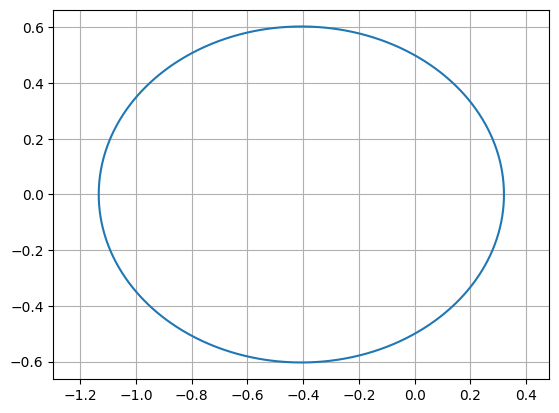

In [123]:
tetaers = np.linspace(0, 2 * np.pi, 1000)
rs = p / (1 + e * np.cos(tetaers))

xfs = rs * np.cos(tetaers)
yfs = rs * np.sin(tetaers)

plt.plot(xfs, yfs)
plt.axis('equal')
plt.grid(True)
plt.tight_layout
plt.show()

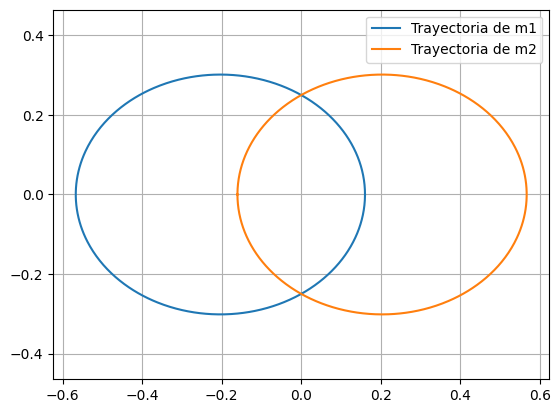

In [124]:
#Conversion de coordenadas de Jacobi a coordenadas de cada particula

M = m1 + m2

rvecs = np.array([xfs, yfs])
rvecs = rvecs.T

r1vecs = m2 / M * rvecs
r2vecs = - m1 / M * rvecs

#plt.plot(xfs, yfs, label='Trayectoria del sistema')
plt.plot(r1vecs[:,0], r1vecs[:,1], label='Trayectoria de m1')
plt.plot(r2vecs[:,0], r2vecs[:,1], label='Trayectoria de m2')
plt.axis('equal')                   
plt.grid(True)
plt.legend()        
plt.show()

#Las posisiones iniciales de las particulas es en los extremos de la figura (el apoapsis), m1 se moveria contrarreloj
#m2 se moveria en sentido horario, ambas con la misma velocidad pero en direcciones opuestas.

Comparación con la teoria de N cuerpos

In [125]:
sistema = [
    dict(r = r1_vec_0, v = v1_vec_0, m = m1),
    dict(r = r2_vec_0, v = v2_vec_0, m = m2)
]

ts = np.linspace(0, 10, 300)
rs, vs, rps, vps, cuadratura = pc.ncuerpos_solucion(sistema, ts)

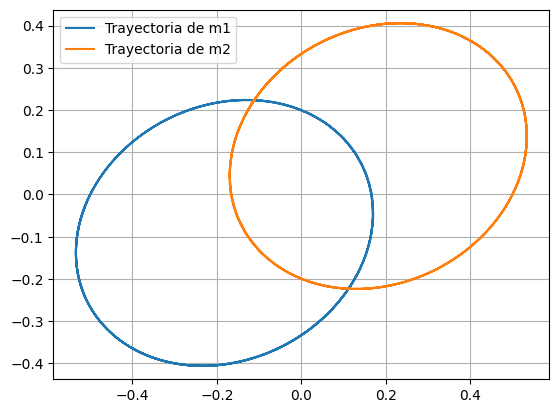

In [126]:
plt.plot(rps[0,:,0], rps[0,:,1], label='Trayectoria de m1')
plt.plot(rps[1,:,0], rps[1,:,1], label='Trayectoria de m2')
plt.axis('equal')   
plt.grid(True)
plt.legend()
plt.show()

In [127]:
w = np.arccos(e_vec@[1,0,0]/e)

rad = 180 / np.pi # Factor para convertir de radianes a grados
w*rad

np.float64(26.565051177077994)

In [128]:
Rz = np.array([
    [np.cos(w), np.sin(w), 0],
    [-np.sin(w), np.cos(w), 0],
    [0, 0, 1]
])
Rz

array([[ 0.89442719,  0.4472136 ,  0.        ],
       [-0.4472136 ,  0.89442719,  0.        ],
       [ 0.        ,  0.        ,  1.        ]])

In [129]:
Rz_inv = np.linalg.inv(Rz)
Rz_inv

array([[ 0.89442719, -0.4472136 ,  0.        ],
       [ 0.4472136 ,  0.89442719,  0.        ],
       [ 0.        ,  0.        ,  1.        ]])

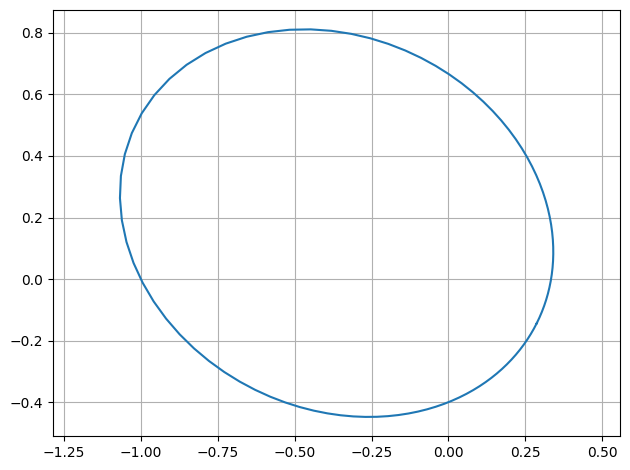

In [130]:
tetaers = np.linspace(0, 2*np.pi, 100)
rs = p / (1 + e*np.cos(tetaers))

xfs = rs * np.cos(tetaers)
yfs = rs * np.sin(tetaers)
zfs = np.zeros_like(xfs)

# Este comando hace la multiplicación matricial
rvecs = (Rz @ np.array([xfs, yfs, zfs])).T

plt.plot(rvecs[:,0], rvecs[:,1])
plt.axis('equal')
plt.grid()
plt.tight_layout()

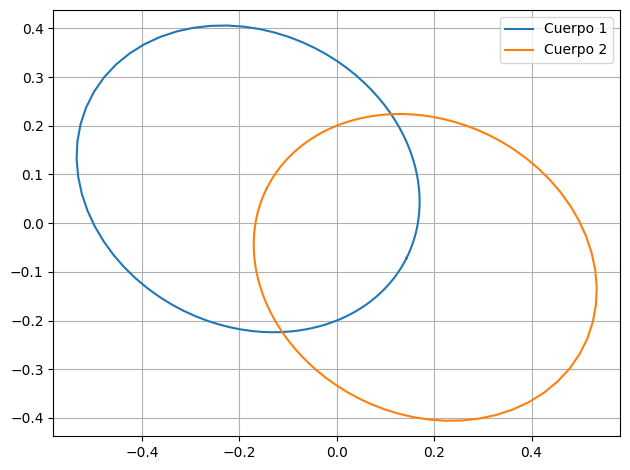

In [131]:
M = m1 + m2

r1vecs = m2/M * rvecs
r2vecs = - m1/M * rvecs

plt.plot(r1vecs[:,0], r1vecs[:,1], label='Cuerpo 1')
plt.plot(r2vecs[:,0], r2vecs[:,1], label='Cuerpo 2')
plt.axis('equal')
plt.grid()
plt.legend()
plt.tight_layout()

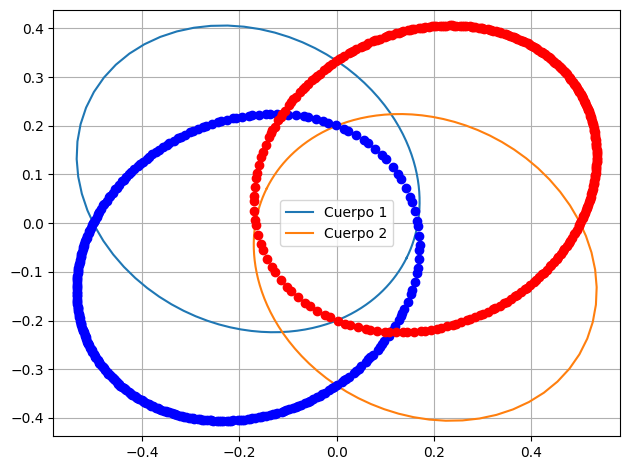

In [132]:
sistema = [
    dict(r = r1_vec_0, v = v1_vec_0, m = m1),
    dict(r = r2_vec_0, v = v2_vec_0, m = m2)
]
ts = np.linspace(0, 10, 300)
rs, vs, rps, vps, cuadratura = pc.ncuerpos_solucion(sistema, ts)

plt.plot(r1vecs[:,0], r1vecs[:,1], label='Cuerpo 1')
plt.plot(r2vecs[:,0], r2vecs[:,1], label='Cuerpo 2')

plt.plot(rps[0,:,0], rps[0,:,1],'bo')
plt.plot(rps[1,:,0], rps[1,:,1],'ro')

plt.axis('equal')
plt.grid()
plt.legend()
plt.tight_layout()

## De elementos orbitales a la orbita en el espacio

In [133]:
deg = np.pi / 180 # Factor para convertir de grados a radianes

In [134]:
#apophis

e = 0.1911663355386932
a = 0.9223803173917017	
q = 0.7460522521429133	
i = 3.340958441017069*deg	
node = 203.8996515621043 *deg
peri = 126.6728325163065 *deg	

p = q * (1 + e)

In [135]:
Rz_omega = spy.rotate(peri,3)
Rx_i = spy.rotate(i,1)
Rz_Omega = spy.rotate(node,3)

M_astro2perifocal = Rz_omega @ Rx_i @ Rz_Omega
M_perifocal2astro = M_astro2perifocal.T

In [136]:
Rz_menos_omega = spy.rotate(-peri,3)
Rx_menos_i = spy.rotate(-i,1)
Rz_menos_Omega = spy.rotate(-node,3)

Dibujar la orbita

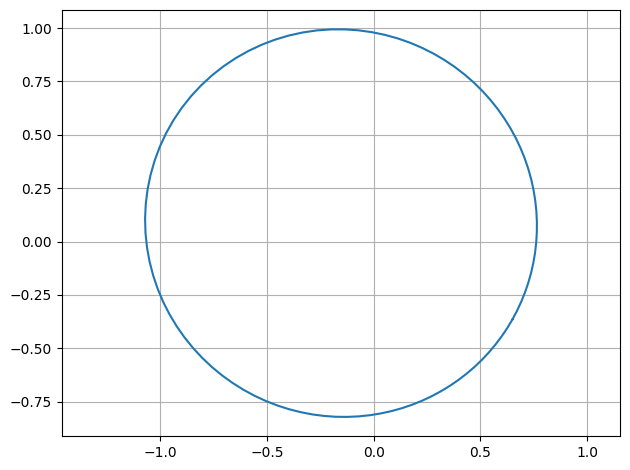

In [137]:
fs = np.linspace(0, 2*np.pi, 100)
rs = p / (1 + e*np.cos(fs))

xfs = rs * np.cos(fs)
yfs = rs * np.sin(fs)
zfs = np.zeros_like(xfs)

# Este comando hace la multiplicación matricial
rvecs = (M_perifocal2astro @ np.array([xfs, yfs, zfs])).T

plt.plot(rvecs[:,0], rvecs[:,1])
plt.axis('equal')
plt.grid()
plt.tight_layout()